In [4]:
import requests
import torch
from PIL import Image
import json
from transformers import MllamaForConditionalGeneration, AutoProcessor

model_id = "/data/chatgpt/data/lekimov/.cache/ellement/chao-test/Llama-3_2-11B-Vision-Instruct/0"

model = MllamaForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
processor = AutoProcessor.from_pretrained(model_id)

# url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/0052a70beed5bf71b92610a43a52df6d286cd5f3/diffusers/rabbit.jpg"
# image = Image.open(requests.get(url, stream=True).raw)

data = json.load(open('/mnt/nushare2/data/mnulli/pretrainingdata/blip_laion_cc_sbu_558k.json'))

image = Image.open(data[0]['image'])
                 
messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": "If I had to write a haiku for this one, it would be: "}
    ]}
]
input_text = processor.apply_chat_template(messages, add_generation_prompt=True)
inputs = processor(
    image,
    input_text,
    add_special_tokens=False,
    return_tensors="pt"
).to(model.device)

output = model.generate(**inputs, max_new_tokens=30)
print(processor.decode(output[0]).split('<|end_header_id|>')[1])

The model weights are not tied. Please use the `tie_weights` method before using the `infer_auto_device` function.


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]



<|image|>If I had to write a haiku for this one, it would be: <|eot_id|><|start_header_id|>assistant


In [1]:
import os

# os.environ['HTTP_PROXY'] = 'http://httpproxy-tcop.vip.ebay.com:80'
# os.environ['HTTPS_PROXY'] = 'http://httpproxy-tcop.vip.ebay.com:80'
# os.environ['http_proxy'] = 'http://httpproxy-tcop.vip.ebay.com:80'
# os.environ['https_proxy'] = 'http://httpproxy-tcop.vip.ebay.com:80'

os.environ['https_proxy'] = 'genai-h100.inference.vip.ebay.com:80'

# os.environ['HUGGINGFACE_HUB_CACHE'] = '/mnt/nushare/data/mnulli/.cache/huggingface/hub'
# os.environ['HF_HOME'] = '/mnt/nushare/data/mnulli/.cache/huggingface'
# os.environ['HF_DATASETS_CACHE'] = '/mnt/nushare/data/mnulli/.cache/huggingface/datasets'
# os.environ['TORCH_EXTENSIONS_DIR'] = '/home/mnulli/.llm_cache/torch_cache'
# os.environ['TRANSFORMERS_CACHE'] = '/mnt/nushare/data/mnulli/.cache/huggingface/hub'


In [7]:
from pychomsky.utils.auth import ProdAuthTokenProvider
import os

# proxy_url="http://httpproxy-tcop.vip.ebay.com:80"
proxy_url=""
os.environ["http_proxy"] = proxy_url
os.environ["HTTP_PROXY"] = proxy_url
os.environ["https_proxy"] = proxy_url
os.environ["HTTPS_PROXY"] = proxy_url
os.environ["no_proxy"] = "krylov,ams,ems,mms,localhost,127.0.0.1,.vip.hadoop.ebay.com,.vip.ebay.com,github.ebay.com,.tess.io,.corp.ebay.com,.ebayc3.com,.qa.ebay.com,.dev.ebay.com"

provider = ProdAuthTokenProvider()
provider.token()

/opt/clients/pykrylov/3.10/latest/install/urllib3/connectionpool.py:1064: InsecureRequestWarning: Unverified HTTPS request is being made to host 'trustfabric.vip.ebay.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(
/opt/clients/pykrylov/3.10/latest/install/urllib3/connectionpool.py:1064: InsecureRequestWarning: Unverified HTTPS request is being made to host 'fidelius.vip.ebay.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(
/opt/clients/pykrylov/3.10/latest/install/urllib3/connectionpool.py:1064: InsecureRequestWarning: Unverified HTTPS request is being made to host 'oauth.stratus.ebay.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(


'v^1.1#i^1#r^0#p^1#I^3#f^0#t^H4sIAAAAAAAAAO1Yb2xTVRRv1224wNAAmbBI7N4ADaav9/a1r+1jLZbBXNlYt7VMXAR97/W+7m3te+XdW7aOBMdUAgYIQuCLEBbUkAgYWNyUP2qyQDQZqOETYvSDZAZngoSQEEJifO3K6CZuwCbsg/uyvHvPPff8fuf87j29oCO/YPGWyi23Co3Tcro6QEeO0Qing4L8vJdmmnKK8wwgy8DY1bGgI7fTdLUM87FonKtHOK4qGJnbYlEFc+lBD5XQFE7lsYw5hY8hzBGRC/pWVXM2GnBxTSWqqEYps3+5h3IgJCIIeQmKDpZlWH1UueszpOrzDC9ApwCR04VYxi3q8xgnkF/BhFeIh7IBm90CoQU4QpDh7CzHANoOYSNlbkAallVFN6EB5U2Hy6XXalmxjh0qjzHSiO6E8vp9FcGAz798RU2ozJrly5vhIUh4ksAjv8rVMDI38NEEGnsbnLbmgglRRBhTVu/QDiOdcr67wTxC+GmqXW6XKAlAcrAOgeGBMClUVqhajCdjx5EakcMWKW3KIYXIJDkeozobQjMSSearRnfhX25O/atL8FFZkpHmoVYs873mq62lvKndkcAnLTFea0EkHuVFZBH1GkrEkCaHOVayQ4kFgkW0M5LF7mR4Cy+6JAuCyAEBdCFoFzJBDO2UScGoKMpVJSynCMXmGpUsQzoiNJo3Jos33SigBDSfRFLRDts5s/gF9sZUwocynCBNSirnKKaTZE5/jp+d4dWEaLKQIGjYw+iJNH0eio/H5TA1ejJdp5nSasMeqomQOGe1tqa03tpKtzK0qkWsNgCgdc2q6qDYhGI8NWwv31vwb8YWOQ1FRPoqLHMkGddjadPrWA9AiVBeO2BZ1pnhfWRY3tGj/xjIwmwdqZbJUo/d4XAJTkkUBMnJu222yVCPN1PA1vHql3FINsYlIUuYdev165Yki+AIsxYoIQQQEgTR7fpfRA8ngyA

In [57]:
import requests
import json
import base64

url = "https://genai-h100.inference.vip.ebay.com/inference/v1/domain/genai-h100/inferenceservice/chao-llm-h100/predict"
token = 'v^1.1#i^1#f^0#r^0#p^1#I^3#t^H4sIAAAAAAAAAO1Yb2wURRTvtddiAxWJBLAp5NxqMJDbm7m9vbsuvcOjLXC2cKVXammiMrs32257t7vszHl3hWipBL8YITEUTYtUIiKY4J8YiYYILYmKRCUhgOIHEaMhmphIiGhUcO9ayrViC7RCP9gvzc68efN+v/d+M+8GdBQULti8fPOlIsuU3N4O0JFrscCpoLAgf+HdebnF+Tkgy8DS2/FAh7Uz73w5QbGoLtRhomsqwbZkLKoSITPoY+KGKmiIKERQUQwTgUpCOLCiRnCyQNANjWqSFmVswUofI0cikhPxwMu7JNkbcZqj6lWf9ZqPgXyZzEPodAIOy24PMOcJieOgSihSqY9xAqfLDqEd8PWQE1y8wPGsiytrYmwN2CCKppomLGD8mXCFzFojK9bRQ0WEYIOaThh/MLA0HAoEK6tW1pc7snz5B3kIU0TjZPhXhRbBtgYUjePRtyEZayEclyRMCOPwD+ww3KkQuBrMLYSfoVqUEXQ73R4IRCBJwDUhVC7VjBiio8eRHlEidjljKmCVKjQ1FqMmG2Irlujg10rTRbDSlv63Ko6iiqxgw8dULQmsCdTWMv707lhEKXsMGW2Y6lEkYbtk1lA8hg0lIrhlF5TdQLRLLk62uzwcsiPJK9sxxDwE0IuhSxwMYmCnwRSMiKJCUyNKmlBiW6nRJdhEhEfyxmXxZhqF1JARkGk62iE7Tza/XFM64QMZjtMWNZ1zHDNJsmU+x87O0GpKDUWMUzzkYeREhj4fg3RdiTAjJzN1OlhaSeJjWijVBYcjkdZ6IsEmOFYzmh1OAKCjcUVNWGrBMcQM2SvXFvybsV3JQJGwuYooAk3pZixJs47NANRmxu8CbrfbM8j78LD8I0f/MZCF2TFcLROlHuSRvADJvCxiN4/cZROhHv9gATvGql+Ol52cV8b2iLvMrN8yWbaLfMRthzLGAGNRlMq8/4vo5mQQxpKB6Q3r4LZo4JGaR8WGdnd1NIQc6jqltS6WqOHWeVPtTUvdze2tdU0t1UmvtCoggWbfjSrluuAroorJTL25fzYBaa3feRKWa4TiyLjghSVNx7VaVJFSkyvBkNBaZNDUuNAFdD144wf4bcE1gWfHrXFyc5faJLzQrouKpOv4v0E12r0+FrK0D2I6QbrCprPOSlrMoSGzX3FkInY8rMdFU3zjwq6YrfCkyqcJcgCtEhnoYdkMZJY8KbEGJlrcMNt3NpRu2+q1NqyaFx01tGgUGw1w3HqPxeIUiVE82YQ/AUWuoEl2C0MPB7zQ7Cr4ceGSMnfsE5PgWLJufPeOndY30ag7hj8p+HMyf7DT0g86LR/mWiygHDwIS8H9BXmrrXnTiolCMasgmSVKs2r+UjYw24ZTOlKM3HtzLuzatryiuCrUtWB9fep498c507JeNHofA3OG3jQK8+DUrAcOUHJtJh9On13kdEEIeMi5eI5vAqXXZq1wlnXmm0Vdia75BxtLuq1r9x7r/eP7Zf07QdGQkcWSn2PttORse6+vYd+51c/3LeIe339+9+IZ7//+4uGjx9/oP/HlvvZkS/LUN7tSpz8qUWZ1f3Dlt03P8Lylp5G9Mvep3LNBx6k9Fzx9U/LXbWiUZ9O9h5tigYufH9rwsgJ+gj09Bwrak+z5fdPOPff6XV+EG+VQ7Lu3g7u7jnzWXGmJLry8fu1XxckfXnkof2Ot1ut69ch++Ze6LQdKgn0/lz+t7y5ZVDXzYseaw2dO+tRLpe8UfbJnzunp1YdOdr0wL29HFw7d07P4rYtHe6pXnwx/PeNb65Yf1y7bP3vKzmfF0qZ5zn6XZr9k29qmneme89om769r5v7VeuJTGmnYPj+VKHzpYO59Z49tJ5f/7NjRn88P5PJvi9pUWGsSAAA='

headers = {
    "Accept": "application/json",
    "Content-Type": "application/json",
    'Authorization': f'Bearer {token}'
}


def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

data = json.load(open('/mnt/nushare2/data/mnulli/pretrainingdata/blip_laion_cc_sbu_558k.json'))

# image = Image.open(data[0]['image'])

image = encode_image(data[0]['image'])

template = "<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 05 Nov 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\n{user_message}<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n"


qs = 'Describe the Image in 3 words maximum.'
qs = "You are a helpful language and vision assistant. You are able to understand the visual content that the user provides, and assist the user with a variety of tasks using natural language." + qs
print('qs', qs)


body = {
    "input": {
        "text_input": [template.format(user_message=qs)],
        "multi_modal_data": [f'{{\n "image": ["{image}"]\n}}'],
        "sampling_parameters": ["{\"max_tokens\": 100, \"temperature\": 0.0}"]
    },
    "appName": "chao-test-llama-3-2-90b-vision-instruct-0-djiv"
}

print(template.format(user_message=qs))

response = requests.post(
    url, 
    headers=headers, 
    data=json.dumps(body), 
    verify=False,
)

print(response.status_code)
print(response.json()['output']['text_output'][0].split('<|eot_id|><|start_header_id|>assistant<|end_header_id|>')[1])

qs You are a helpful language and vision assistant. You are able to understand the visual content that the user provides, and assist the user with a variety of tasks using natural language.Describe the Image in 3 words maximum.
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 05 Nov 2024

<|eot_id|><|start_header_id|>user<|end_header_id|>

You are a helpful language and vision assistant. You are able to understand the visual content that the user provides, and assist the user with a variety of tasks using natural language.Describe the Image in 3 words maximum.<|eot_id|><|start_header_id|>assistant<|end_header_id|>




/opt/clients/pykrylov/3.10/latest/install/urllib3/connectionpool.py:1064: InsecureRequestWarning: Unverified HTTPS request is being made to host 'genai-h100.inference.vip.ebay.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(


200


Bed with mattress.


In [52]:
response.json()['output']['text_output'][0]

'<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 05 Nov 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nYou are a helpful language and vision assistant. You are able to understand the visual content that the user provides, and assist the user with a variety of tasks using natural language.Describe the Image in 3 words maximum.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\nBed with mattress.'

In [1]:
import os
proxy_url="http://httpproxy-tcop.vip.ebay.com:80"
os.environ["http_proxy"] = proxy_url
os.environ["HTTP_PROXY"] = proxy_url
os.environ["https_proxy"] = proxy_url
os.environ["HTTPS_PROXY"] = proxy_url 

os.environ["no_proxy"] = "krylov,ams,ems,mms,localhost,127.0.0.1,.vip.hadoop.ebay.com,.vip.ebay.com,github.ebay.com,.tess.io,.corp.ebay.com,.ebayc3.com,.qa.ebay.com,.dev.ebay.com"

# Load model and tokenizer

In [6]:
model_path = os.path.expanduser(args.model_path)
model_name = get_model_name_from_path(model_path)
tokenizer, model, image_processor, context_len = load_pretrained_model(model_path, args.model_base, model_name)

Loading LLaVA from base model...


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

Some weights of LlavaLlamaForCausalLM were not initialized from the model checkpoint at /mnt/nushare2/data/baliao/multimodal/model_zoos/lilium-2-7b-chat and are newly initialized: ['model.mm_projector.0.bias', 'model.mm_projector.0.weight', 'model.mm_projector.2.bias', 'model.mm_projector.2.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading additional LLaVA weights...
Loading LoRA weights...
Merging LoRA weights...
Model is loaded...


# QA

In [104]:
# path1 = "/mnt/nushare2/data/baliao/multimodal/data/ebay_imgs/outdoor_bbq.png"
path2 = "/mnt/nushare2/data/mnulli/1m-images/364488475417.0.jpg"
path3 = "/mnt/nushare2/data/mnulli/1m-images-fashion/116262872754.0.jpg"
path4 = "/mnt/nushare2/data/mnulli/1m-images/225600173734.0.jpg"
path5 = '/mnt/nushare2/data/mnulli/1m-images-fashion/116263241432.0.jpg'
path6 = '/mnt/nushare2/data/mnulli/1m-images-fashion/116263201443.0.jpg'
path7 = '/mnt/nushare2/data/mnulli/1m-images-fashion/116263275879.0.jpg'
path_air_jordan = "/mnt/nushare2/data/baliao/multimodal/data/ebay_imgs/air_jordan.jpeg"
path8 = '/mnt/nushare2/data/mnulli/1m-images-fashion/116263280526.0.jpg'
path9 = '/mnt/nushare2/data/mnulli/1m-images-fashion/116263282774.0.jpg'
path10 = '/mnt/nushare2/data/mnulli/1m-images-fashion/116263371723.0.jpg'
path11 = '/mnt/nushare2/data/mnulli/1m-images-fashion/116251256818.0.jpg'
path12 = '/mnt/nushare2/data/mnulli/1m-images-fashion/116263218788.0.jpg'
path13 = '/mnt/nushare2/data/mnulli/1m-images-fashion/116263226102.0.jpg'

args.img_path = path13

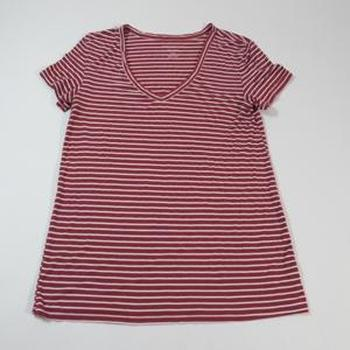

<s>[INST] <<SYS>> <image>
You are a helpful language and vision assistant. You are able to understand the visual content that the user provides, and assist the user with a variety of tasks using natural language.
<</SYS>>

Answer the following question sequentially. 
What is the material of the T-Shirt? [/INST]


In [105]:
image = Image.open(args.img_path)
display(image)
question = "Answer the following question sequentially. \nWhat is the material of the T-Shirt?"
prompt = f"""<s>[INST] <<SYS>> <image>
You are a helpful language and vision assistant. You are able to understand the visual content that the user provides, and assist the user with a variety of tasks using natural language.
<</SYS>>

{question} [/INST]"""
print(prompt)

In [106]:
# image = Image.open(args.img_path)
# display(image)
image_tensor = process_images([image], image_processor, model.config)[0]
images = image_tensor.unsqueeze(0).half().cuda()
image_sizes = [image.size]

In [107]:
input_ids = tokenizer_image_token(prompt, tokenizer, IMAGE_TOKEN_INDEX, return_tensors='pt').unsqueeze(0).cuda()
with torch.inference_mode():
    output_ids = model.generate(
        input_ids,
        images=images,
        image_sizes=image_sizes,
        do_sample=True if args.temperature > 0 else False,
        temperature=args.temperature,
        max_new_tokens=1024,
        use_cache=True,
    )
out = tokenizer.batch_decode(output_ids, skip_special_tokens=True)[0].strip()


In [108]:
print(out)

The material of the T-Shirt is cotton.


In [109]:
import json
err_examples = {}

qa = {}
qa['Question'] = question
qa['Answer'] = out

err_examples[args.img_path] = qa


f = open("matteo_data/erroneous_examples.json")

examples = json.load(f)

if len(examples) >= 1:
    err_examples.update(examples)

with open("matteo_data/erroneous_examples.json", "w") as final:
        json.dump(err_examples, final) 

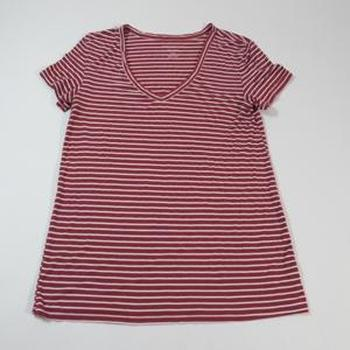

Question:  Answer the following question sequentially. 
What is the material of the T-Shirt? 
Wrong Answer:  The material of the T-Shirt is cotton.
--------------------
Correct Answer:  [{'from': 'human', 'value': '<image>What is the main department of this T-Shirt?'}, {'from': 'gpt', 'value': 'This T-Shirt is from the Women department.'}, {'from': 'human', 'value': 'What is the main material of this T-Shirt?'}, {'from': 'gpt', 'value': 'This T-Shirt is primarily made of Viscose.'}, {'from': 'human', 'value': 'What is the main fit for the T-Shirt?'}, {'from': 'gpt', 'value': 'The T-Shirt is of Regular fit.'}, {'from': 'human', 'value': 'What is the Color of the T-Shirt?'}, {'from': 'gpt', 'value': 'The Color of the T-Shirt is Multicolor'}, {'from': 'human', 'value': 'What is the brand of the T-Shirt?'}, {'from': 'gpt', 'value': 'The brand of the T-Shirt is American Eagle Outfitters.'}, {'from': 'human', 'value': 'What is the main theme of the T-Shirt?'}, {'from': 'gpt', 'value': 'The c

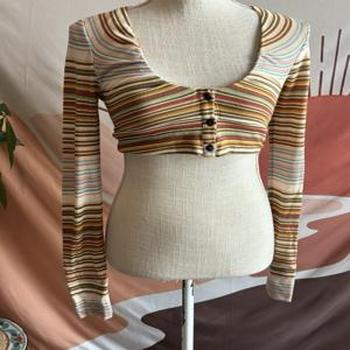

Question:  Answer the following question sequentially. 
What is the Color of the Blouse? 
Wrong Answer:  White
--------------------
Correct Answer:  [{'from': 'human', 'value': '<image>What is the main department of this Blouse?'}, {'from': 'gpt', 'value': 'This Blouse is from the Women department.'}, {'from': 'human', 'value': 'What is the Color of the Blouse?'}, {'from': 'gpt', 'value': 'The Color of the Blouse is Multicolor'}, {'from': 'human', 'value': 'What is the brand of the Blouse?'}, {'from': 'gpt', 'value': 'The brand of the Blouse is Urban Outfitters.'}]


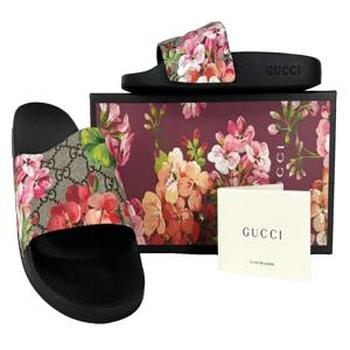

Question:  Answer the following question sequentially. 
Which is the most appropriate occasion to wear these in? 
What is the color of this item? 
Wrong Answer:  The most appropriate occasion to wear these Gucci sandals would be during a casual outing or a beach vacation. The sandals are black in color.
--------------------
Correct Answer:  [{'from': 'human', 'value': '<image>What is the main department of this Flat?'}, {'from': 'gpt', 'value': 'This Flat is from the Women department.'}, {'from': 'human', 'value': 'In which occasion could this Flat be worn?'}, {'from': 'gpt', 'value': 'The Flat can be worn in a Casual occasion.'}, {'from': 'human', 'value': 'What is the Color of the Flat?'}, {'from': 'gpt', 'value': 'The Color of the Flat is Pink Multicolor'}, {'from': 'human', 'value': 'What is the brand of the Flat?'}, {'from': 'gpt', 'value': 'The brand of the Flat is Gucci.'}, {'from': 'human', 'value': 'What is the main theme of the Flat?'}, {'from': 'gpt', 'value': 'The character

In [114]:
f = open("matteo_data/erroneous_examples.json")

v2_data = open('/data/chatgpt/notebooks/mnulli/1M_image_listings/data/v2_multi.json')

examples = json.load(f)
v2_data = json.load(v2_data)


for key, value in examples.items():
    image = Image.open(key)
    display(image)
    
    print("Question: ", value['Question'], "\nWrong Answer: ", value['Answer'])
    print("--"*10)
    for x in v2_data:
        if x['image'] == key:
            print("Correct Answer: ", x['conversations'])

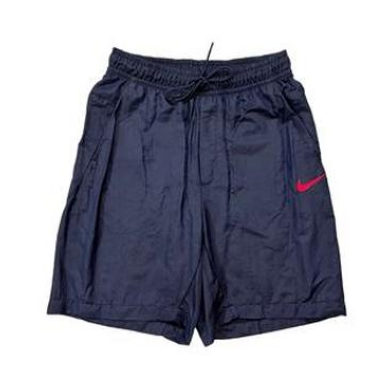

In [211]:
img = Image.open(args.img_path)
plt.imshow(img)
plt.axis('off')
plt.show()

In [212]:
print(f"Question: {question}")
print(f"Answer: {out}")

Question: Answer the following question sequentially. 
What is the object brand? 
Where can I buy this object? 
What is its color? 
What is the item condition? 
Is the item vintage?
Answer: The object brand is Nike. You can buy this item at a sporting goods store or online. The color of the item is blue. The item is in good condition. No, the item is not vintage.


In [ ]:
import os
import io
import json
import torch
import base64
import requests

from tqdm import tqdm
from PIL import Image
import pandas as pd
from transformers import AutoProcessor, LlavaForConditionalGeneration


# model_id = "/mnt/nushare2/data/vorshulevich/vlm/hf_models/lilium-2-vl-7b-chat"
# model_id = "/mnt/nushare2/data/vorshulevich/vlm/hf_models/lilium-2-vl-7b-chat-json"
# model_id = "/mnt/nushare2/data/vorshulevich/vlm/hf_models/lilium-2-vl-7b-chat-dae"
# model_id = "/mnt/nushare2/data/vorshulevich/vlm/hf_models/lilium-2-vl-7b-chat-dae-unbalanced"
# model_id = "/mnt/nushare2/data/vorshulevich/vlm/hf_models/lilium-2-vl-7b-chat-dae-us_set_jsons"
# model_id = "/mnt/nushare2/data/vorshulevich/vlm/hf_models/lilium-2-vl-7b-chat-dae-us_set"
# model_id = "/mnt/nushare2/data/vorshulevich/vlm/hf_models/ellama-31-vl-7b-chat-dae-unbalanced"
# model_id = "/mnt/nushare2/data/vorshulevich/vlm/hf_models/ellama-31-vl-7b-chat-dae-us_set"
model_id = "/mnt/nushare2/data/vorshulevich/vlm/hf_models/ellama-31-vl-7b-chat-dae-us_set_json"


model_ = LlavaForConditionalGeneration.from_pretrained(
    model_id, 
    torch_dtype=torch.float16, 
).to(0)

processor_ = AutoProcessor.from_pretrained(model_id)

df = pd.read_csv("/data/chatgpt/notebooks/vorshulevich/llava/attributes_extraction_vlm_eval_data_gpt_preds.csv")

result = df[:150]
del result["ITEM_ID"]
del result["CHATGPT-4O Title"]
del result["AUCT_TITL"]
del result["LEAF_CATEG_ID"]
del result["Total"]


Loading checkpoint shards:   0%|          | 0/7 [00:00<?, ?it/s]

In [11]:
# question = "<image>\n Answer only with what you can see in the image. Given one image per product, identify all visually presented attributes in a structured format for accurate listing details. Each type of product should have a different set of attributes which are relevant in an ecommerce context. Please return them in json format. "

# jsons
# question = "<image>\nAnswer only with what you can see in the image. Given one image per product identify all the visually presented attributes in a structured format for accurate listing details. Each type of product should have a different set of attributes which are relevant in an ecommerce context. "
# question += "Do not generate description and title. Do not repeat aspect values nor categories. "
# question += "Please return them in json format like this {'attributes': {'attribute_name_1': 'attribute_value_1', 'attribute_name_2': 'attribute_value_2', ..}"

# dae
question = "<image>\n Given one image per product, determine all relevant attributes and provide the output in JSON format. Limit youself to not more than 5 attributes per image."
prompt = f"""<s>[INST] <<SYS>>

You are a helpful language and vision assistant. You are able to understand the visual content that the user provides, and assist the user with a variety of tasks using natural language.
<</SYS>>

{question}[/INST]"""

image_paths = os.listdir("/mnt/nushare2/data/vorshulevich/dae_images/")


OUTPUT_FOLDER='/mnt/nushare2/data/vorshulevich/dae_images/'

images_and_captions = []
for i in tqdm(range(len(result))):
    image_path = result["gallery_url"][i]
    try:
        filename = image_path.split("/")[-2] + ".jpg"
        file_path = os.path.join(OUTPUT_FOLDER, filename)
        print(file_path)
        image = Image.open(file_path)
    except:
        print(f'There is no for {image_path}')
        continue
        
    inputs = processor_(images=image, text=prompt, return_tensors='pt').to(0, torch.float16)

    output = model_.generate(
        **inputs, 
        max_new_tokens=150,
        temperature=1.0,
    )
    answer = processor_.decode(output[0][len(inputs["input_ids"][0]):], skip_special_tokens=True).strip()
    
    answer = answer.split("}")[0] + "}"
    
    print(answer)

    base_width = 300
    wpercent = (base_width / float(image.size[0]))
    hsize = int((float(image.size[1]) * float(wpercent)))
    image = image.resize((base_width, hsize), Image.Resampling.LANCZOS)

    images_and_captions.append((image, answer, result["CHATGPT-4O Attributes"][i]))



# Function to convert Pillow image to a Base64 data URI
def image_to_data_uri(image):
    buffer = io.BytesIO()
    image.save(buffer, format="PNG")
    buffer.seek(0)
    img_str = base64.b64encode(buffer.read()).decode("utf-8")
    return f"data:image/png;base64,{img_str}"

# Generate HTML content
html_content = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Image Table</title>
    <style>
        table {
            width: 100%;
            border-collapse: collapse;
        }
        th, td {
            border: 1px solid #ddd;
            padding: 8px;
            text-align: center;
        }
        img {
            max-width: 100px;
            max-height: 100px;
        }
    </style>
</head>
<body>
    <table>
        <tr>
            <th>Image</th>
            <th>Caption 1</th>
            <th>Caption 2</th>
        </tr>
"""

# Add rows for each image and caption
for image, caption1, caption2 in images_and_captions:
    data_uri = image_to_data_uri(image)
    html_content += f"""
        <tr>
            <td><img src="{data_uri}" alt="Image"></td>
            <td>{caption1}</td>
            <td>{caption2}</td>
        </tr>
    """

# Close the HTML table and body
html_content += """
    </table>
</body>
</html>
"""

# Save to an HTML file
with open("image_table_to_compare.html", "w") as html_file:
    html_file.write(html_content)

print("HTML file 'image_table.html' created successfully.")

  0%|          | 0/150 [00:00<?, ?it/s]

/mnt/nushare2/data/vorshulevich/dae_images/R-sAAOSwjTlhr7Uj.jpg


  1%|          | 1/150 [00:01<04:01,  1.62s/it]

{'Style': 'Cardigan', 'Size Type': 'Regular', 'Color': 'Brown', 'Brand': 'Unbranded', 'Type': 'Sweater', 'Material': 'Acrylic', 'Fabric Type': 'Knit', 'Size': 'One Size', 'Department': 'Women'}
/mnt/nushare2/data/vorshulevich/dae_images/Y2kAAOSwUGViAZ6T.jpg


  1%|▏         | 2/150 [00:02<03:25,  1.39s/it]

...

 99%|█████████▊| 148/150 [04:53<00:03,  1.93s/it]

{'Brand': 'One A Day', 'Type': 'Vitamin', 'Form': 'Capsule', 'Active Ingredients': 'Folic Acid', 'Ingredients': 'Folic Acid', 'Department': 'Women'}
There is no for nan
/mnt/nushare2/data/vorshulevich/dae_images/2ccAAOSwX6hnP7Zz.jpg


100%|██████████| 150/150 [04:55<00:00,  1.97s/it]

{'Attribute/MTG:Color': 'Water', 'Set': 'Sword & Shield - Silver Tempest', 'Card Type': 'Pokémon', 'Manufacturer': 'Nintendo', 'Card Name': 'Galvantula V', 'Game': 'Pokémon TCG', 'Features': 'Full Art', 'Card Number': '215/195', 'Finish': 'Holo', 'Character': 'Galvantula', 'Creature/Monster Type': 'Water'}


HTML file 'image_table.html' created successfully.
